# 第二阶段：2RC＋双节点热模型辨识

## 研究问题

能否用计算量较低的二阶 RC 电模型和双节点热模型，逼近 Chen2020 DFN 虚拟电芯在 25 ℃、10%–80% SOC 附近的电压、SOC 和平均温度动态？

**成功标准：**独立验证集电压 RMSE 不超过 50 mV，平均温度 RMSE 不超过 1.5 ℃。验证轨迹不参加参数拟合。

## 模型和符号约定

项目规定充电电流 (I>0)。二阶 RC 模型为

\[
\frac{dz}{dt}=\frac{I}{3600Q_n},\qquad
\frac{dv_j}{dt}=-\frac{v_j}{R_jC_j}+\frac{I}{C_j},\quad j\in\{1,2\},
\]

\[
V=U_{oc}(z)+R_0I+v_1+v_2.
\]

双节点热模型为

\[
C_c\dot T_c=q-\frac{T_c-T_s}{R_{cs}},\qquad
C_s\dot T_s=\frac{T_c-T_s}{R_{cs}}-\frac{T_s-T_a}{R_{sa}}.
\]

Chen2020 集总热模型只提供平均温度，因此仅验证 (T_{avg}=0.8T_c+0.2T_s)。核心和表面温度是潜在状态，不作为已独立验证的真实温度。

## 实验计划

1. 在 10%–80% SOC 读取平衡 OCV；
2. 在多个 SOC 施加 0.5C、1C、2C 短充电脉冲并静置，辨识 2RC；
3. 使用多档长脉冲和冷却轨迹辨识热模型；
4. 在未参与拟合的动态电流轨迹上验证；
5. 导出参数、误差、图形和适用边界。

In [1]:
from pathlib import Path
import json
import os
import pandas as pd
from IPython.display import Image, display

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")

# 无论从项目根目录还是 notebooks 目录启动，都自动找到配置和输出。
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase2.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase2_config import load_phase_two_config
from battery_fast_charge.phase2_runner import run_phase_two

config = load_phase_two_config(PROJECT_ROOT / "configs" / "phase2.yaml")
print(f"研究: {config.study_name}")
print(f"采样周期: {config.experiment.sample_period_s:g} s")

研究: chen2020_phase2_reduced_model
采样周期: 5 s


## 运行或复用正式结果

交付版本包含完整结果。将 `RUN_PHASE2` 改为 `True` 会重新运行多组 DFN 虚拟试验和参数优化，耗时明显长于读取缓存。

In [2]:
RUN_PHASE2 = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase2_validation_metrics.json"
parameters_path = PROJECT_ROOT / "outputs" / "metrics" / "phase2_identified_parameters.json"
if RUN_PHASE2 or not (metrics_path.exists() and parameters_path.exists()):
    run_phase_two(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
parameters = json.loads(parameters_path.read_text(encoding="utf-8"))
ocv = pd.read_csv(PROJECT_ROOT / "data" / "phase2" / "ocv_curve.csv")
display(ocv.round(5))

,soc,ocv_v
0,0.1,3.29591
1,0.2,3.48519
2,0.3,3.58145
3,0.4,3.66701
4,0.5,3.75087
5,0.6,3.84058
6,0.7,3.94791
7,0.8,4.04208


## OCV与脉冲表征

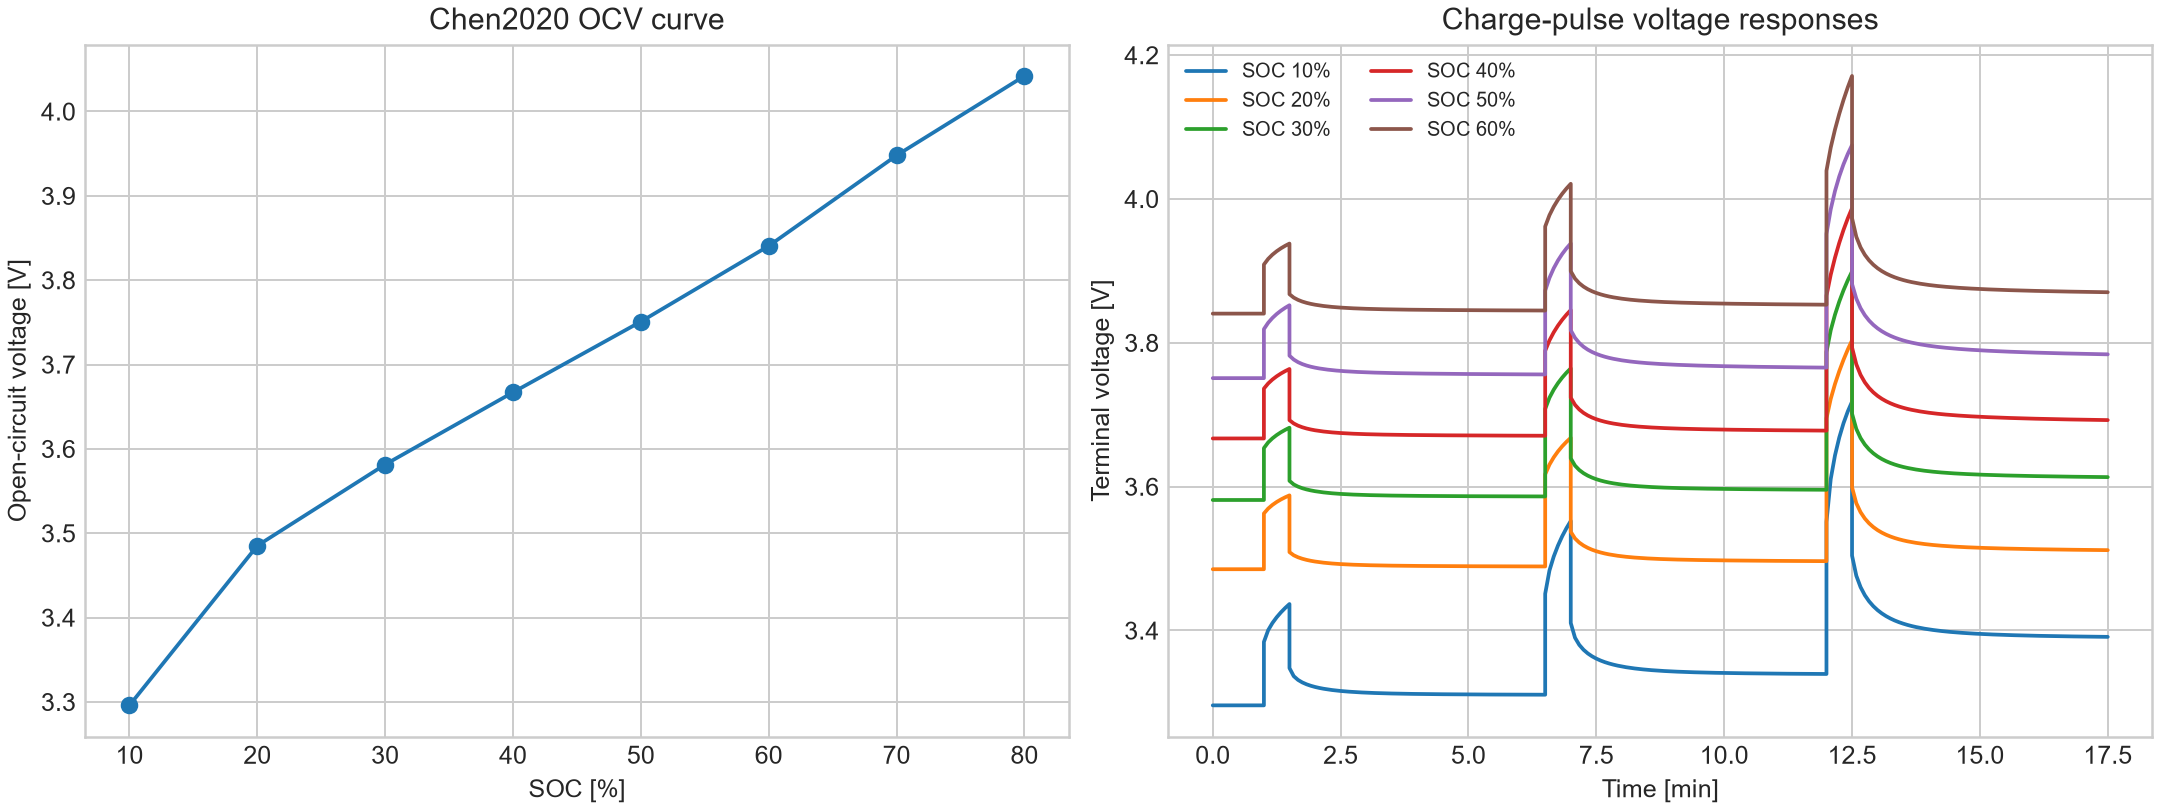

In [3]:
display(Image(filename=str(
    PROJECT_ROOT / "outputs" / "figures" / "phase2_characterization.png"
)))

## 已辨识参数

In [4]:
electrical = pd.Series(parameters["electrical_2rc"], name="value")
thermal = pd.Series(parameters["thermal_two_node"], name="value")
display(electrical.to_frame())
display(thermal.to_frame())

,value
r0_ohm,0.021341
r1_ohm,0.009118
tau1_s,17.243602
r2_ohm,0.015567
tau2_s,150.505388
c1_f,1891.099556
c2_f,9668.181891


,value
total_heat_capacity_j_per_k,71.152893
r_core_surface_k_per_w,0.010000
r_surface_ambient_k_per_w,10.929224
heat_gain,1.099067


## 独立动态轨迹验证

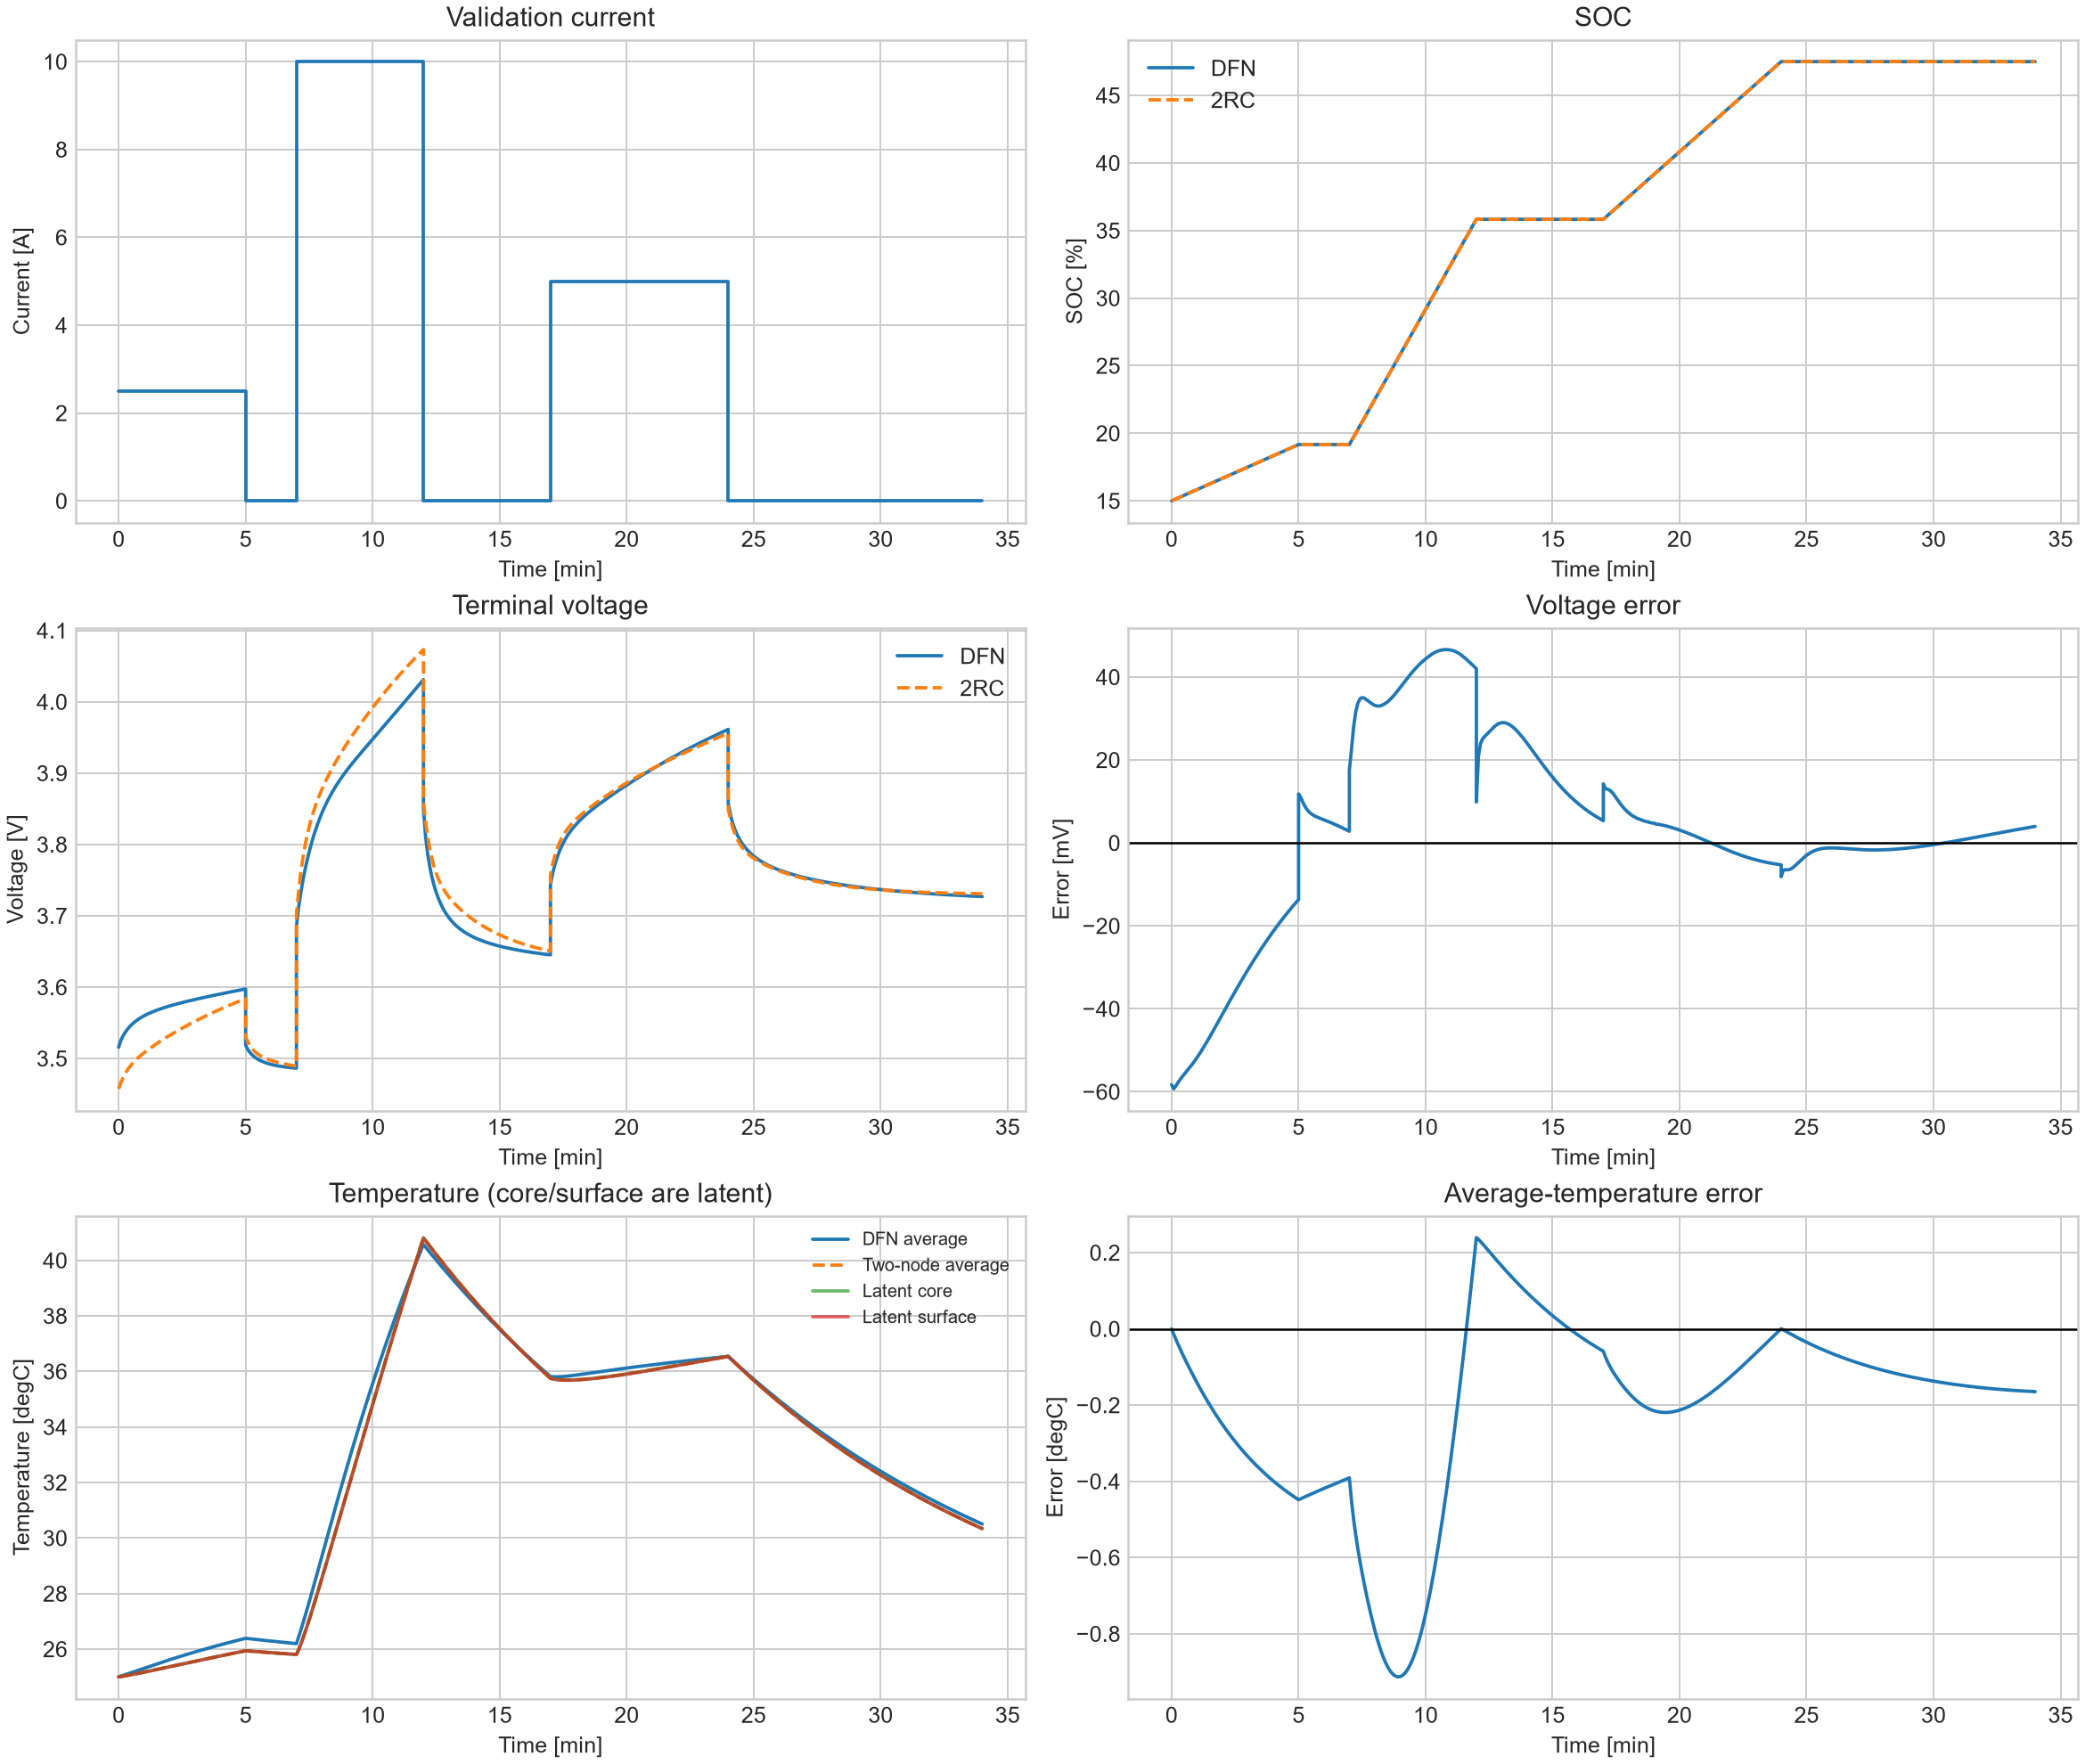

,metric,value
0,voltage_rmse_mv,23.007763
1,temperature_rmse_c,0.31781
2,overall_success,True


In [5]:
display(Image(filename=str(
    PROJECT_ROOT / "outputs" / "figures" / "phase2_reduced_model_validation.png"
)))

summary = pd.DataFrame({
    "metric": ["voltage_rmse_mv", "temperature_rmse_c", "overall_success"],
    "value": [
        metrics["validation"]["voltage"]["rmse_mv"],
        metrics["validation"]["average_temperature"]["rmse_c"],
        metrics["success"],
    ],
})
display(summary)

## 解释与下一步

- 通过验收只表示降阶模型在当前 25 ℃和已验证激励范围内足够准确，不表示它在所有电芯、温度、老化状态下都有效；
- 核心/表面温度没有独立观测，而且核心—表面热阻命中优化下限，两个节点退化为近似同温；因此未来 MPC 第一版应控制平均温度并保留安全裕量，不能宣称核心温度已经验证；
- 若独立验证通过，下一阶段可在此模型上构建带电压、电流、温度和电流变化率约束的 MPC；
- MPC 最终仍需回到 DFN 虚拟电芯上做闭环验证，不能只在自己的简化模型上证明有效。